## Part 2: Student Performance Dataset


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv("student.csv")

print(df.head())
print(df.shape)

   StudentID     Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0        1.0     John    Male            85.0               15.0   
1        2.0    Sarah  Female            90.0               20.0   
2        3.0     Alex    Male            78.0               10.0   
3        4.0  Michael    Male            92.0               25.0   
4        5.0     Emma  Female             NaN               18.0   

   PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  \
0           78.0                        1.0            High        80.0   
1           85.0                        2.0          Medium        87.0   
2           65.0                        0.0             Low        68.0   
3           90.0                        3.0            High        92.0   
4           82.0                        2.0          Medium        85.0   

   Study Hours  Attendance (%) Online Classes Taken  
0          4.8            59.0                False  
1          2.2            70.0  

In [4]:
df.tail()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
995,NaN,Kenneth Murray,Male,85.0,20.0,NaN,1.0,High,72.0,0.8,80.0,True
996,4497.0,Amy Stout,Female,91.0,NaN,86.0,0.0,High,90.0,3.9,80.0,True
997,1886.0,NaN,Male,85.0,8.0,82.0,2.0,Low,68.0,0.4,54.0,False
998,7636.0,Joseph Sherman,Male,88.0,17.0,60.0,2.0,High,85.0,0.9,53.0,True
999,8021.0,Maria Walls,Female,88.0,10.0,90.0,1.0,Medium,NaN,2.4,94.0,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB


In [6]:
df.columns

Index(['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek',
       'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport',
       'FinalGrade', 'Study Hours', 'Attendance (%)', 'Online Classes Taken'],
      dtype='object')

In [7]:
df.dtypes


,0
StudentID,float64
Name,object
Gender,object
AttendanceRate,float64
StudyHoursPerWeek,float64
PreviousGrade,float64
ExtracurricularActivities,float64
ParentalSupport,object
FinalGrade,float64
Study Hours,float64


In [8]:
df.isnull().sum()

,0
StudentID,40
Name,34
Gender,48
AttendanceRate,40
StudyHoursPerWeek,50
PreviousGrade,33
ExtracurricularActivities,43
ParentalSupport,22
FinalGrade,40
Study Hours,24


In [9]:
df.drop(columns='StudentID',inplace=True)

In [10]:
df.drop(columns='Name',inplace=True)

In [11]:
df.loc[:,'Gender'].dtype

dtype('O')

In [12]:
df.loc[:,'Gender'].mode()[0]

'Male'

In [13]:
df.loc[:,'Gender']=df.loc[:,'Gender'].fillna(df.loc[:,'Gender'].mode()[0])

In [14]:
df.loc[:,'Gender'].isnull().sum()

np.int64(0)

In [15]:
df.loc[:,'AttendanceRate'].dtype

dtype('float64')

In [16]:
df.loc[:,'AttendanceRate'].skew()

np.float64(-0.8143818673692191)

In [17]:
df.loc[:,'AttendanceRate'].median()

88.0

In [18]:
df.loc[:,'AttendanceRate']=df.loc[:,'AttendanceRate'].fillna(df.loc[:,'AttendanceRate'].median())

In [20]:
df.loc[:,'AttendanceRate'].isnull().sum()

np.int64(0)

In [21]:
df.loc[:,'StudyHoursPerWeek'].dtype

dtype('float64')

In [22]:
df.loc[:,'StudyHoursPerWeek'].skew()

np.float64(0.2594293462721186)

In [23]:
df.loc[:,'StudyHoursPerWeek'].mean()

np.float64(17.630526315789474)

In [24]:
df.loc[:,'StudyHoursPerWeek']=df.loc[:,'StudyHoursPerWeek'].fillna(df.loc[:,'StudyHoursPerWeek'].mean())

In [25]:
df.loc[:,'StudyHoursPerWeek'].isnull().sum()

np.int64(0)

In [26]:
df.loc[:,'PreviousGrade'].dtype

dtype('float64')

In [27]:
df.loc[:,'PreviousGrade'].skew()

np.float64(-0.5056585176744719)

In [28]:
df.loc[:,'PreviousGrade'].median()

78.0

In [29]:
df.loc[:,'PreviousGrade']=df.loc[:,'PreviousGrade'].fillna(df.loc[:,'PreviousGrade'].median())

In [30]:
df.loc[:,'PreviousGrade'].isnull().sum()

np.int64(0)

In [31]:
df.loc[:,'ExtracurricularActivities'].dtype

dtype('float64')

In [32]:
df.loc[:,'ExtracurricularActivities'].skew()

np.float64(0.0007998175282077034)

In [33]:
df.loc[:,'ExtracurricularActivities'].mean()

np.float64(1.5203761755485894)

In [34]:
df.loc[:,'ExtracurricularActivities']=df.loc[:,'ExtracurricularActivities'].fillna(df.loc[:,'ExtracurricularActivities'].mean())

In [35]:
df.loc[:,'ExtracurricularActivities'].isnull().sum()

np.int64(0)

In [36]:
df.loc[:,'ParentalSupport'].dtype

dtype('O')

In [37]:
df.loc[:,'ParentalSupport'].mode()[0]

'High'

In [38]:
df.loc[:,'ParentalSupport']=df.loc[:,'ParentalSupport'].fillna(df.loc[:,'ParentalSupport'].mode()[0])

In [39]:
df.loc[:,'ParentalSupport'].isnull().sum()

np.int64(0)

In [40]:
df.loc[:,'FinalGrade'].dtype

dtype('float64')

In [41]:
df.loc[:,'FinalGrade'].skew()

np.float64(-0.5174010563628026)

In [42]:
df.loc[:,'FinalGrade'].median()

80.0

In [43]:
df.loc[:,'FinalGrade']=df.loc[:,'FinalGrade'].fillna(df.loc[:,'FinalGrade'].median())

In [44]:
df.loc[:,'FinalGrade'].isnull().sum()

np.int64(0)

In [45]:
df.loc[:,'Study Hours'].dtype

dtype('float64')

In [46]:
df.loc[:,'Study Hours'].skew()

np.float64(-0.8906278735132253)

In [47]:
df.loc[:,'Study Hours'].median()

2.5

In [48]:
df.loc[:,'Study Hours']=df.loc[:,'Study Hours'].fillna(df.loc[:,'Study Hours'].median())

In [49]:
df.loc[:,'Study Hours'].isnull().sum()

np.int64(0)

In [50]:
df.loc[:,'Attendance (%)'].dtype

dtype('float64')

In [51]:
df.loc[:,'Attendance (%)'].skew()

np.float64(2.555722704001934)

In [52]:
df.loc[:,'Attendance (%)'].median()

76.0

In [53]:
df.loc[:,'Attendance (%)']=df.loc[:,'Attendance (%)'].fillna(df.loc[:,'Attendance (%)'].median())

In [54]:
df.loc[:,'Attendance (%)'].isnull().sum()

np.int64(0)

In [55]:
df.loc[:,'Online Classes Taken'].dtype

dtype('O')

In [56]:
df.loc[:,'Online Classes Taken'].mode()[0]

True

In [57]:
df.loc[:,'Online Classes Taken']=df.loc[:,'Online Classes Taken'].fillna(df.loc[:,'Online Classes Taken'].mode()[0])

/tmp/ipykernel_424/2203469655.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[:,'Online Classes Taken']=df.loc[:,'Online Classes Taken'].fillna(df.loc[:,'Online Classes Taken'].mode()[0])


In [58]:
df.loc[:,'Online Classes Taken'].isnull().sum()

np.int64(0)

In [59]:
df.isnull().sum()

,0
Gender,0
AttendanceRate,0
StudyHoursPerWeek,0
PreviousGrade,0
ExtracurricularActivities,0
ParentalSupport,0
FinalGrade,0
Study Hours,0
Attendance (%),0
Online Classes Taken,0


In [60]:
def category(x):
    if x <= 40:
        return "Low"
    elif x <= 70:
        return "Medium"
    else:
        return "High"

df["Performance"] = df["FinalGrade"].apply(category)

##**Part A**

In [61]:
df_encoded = pd.get_dummies(df, drop_first=False)
print(df_encoded.columns)

Index(['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
       'ExtracurricularActivities', 'FinalGrade', 'Study Hours',
       'Attendance (%)', 'Gender_Female', 'Gender_Male',
       'ParentalSupport_High', 'ParentalSupport_Low', 'ParentalSupport_Medium',
       'Online Classes Taken_False', 'Online Classes Taken_True',
       'Performance_High', 'Performance_Medium'],
      dtype='object')


In [62]:
X = df_encoded.drop(["Performance_Medium","Performance_High"], axis=1)
y = df["Performance"]

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [65]:
y_pred =model.predict(X_test)

In [66]:
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 1.0


[[160   0]
 [  0  40]]


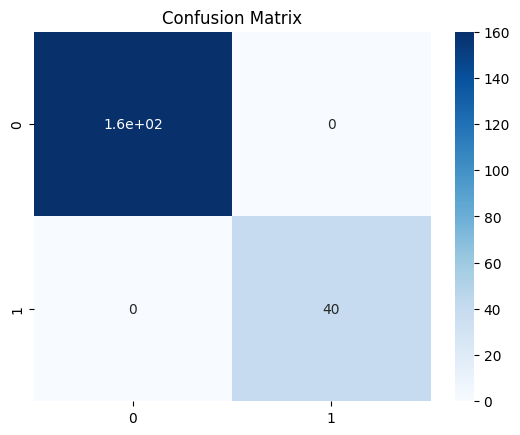

In [67]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

##**Part B**

In [69]:
X2 = df_encoded.drop("FinalGrade", axis=1)
y2 = df_encoded["FinalGrade"]

In [70]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [71]:
model = LinearRegression()
model.fit(X_train2, y_train2)

LinearRegression()

In [72]:
y_pred2 = model.predict(X_test2)

In [75]:
r2 = r2_score(y_test2, y_pred2)
mae = mean_absolute_error(y_test2, y_pred2)
mse = mean_squared_error(y_test2, y_pred2)

print("R2:", r2)
print("MAE:", mae)
print("MSE:", mse)

R2: 0.6020626655842709
MAE: 5.193070307912012
MSE: 35.732534233026385


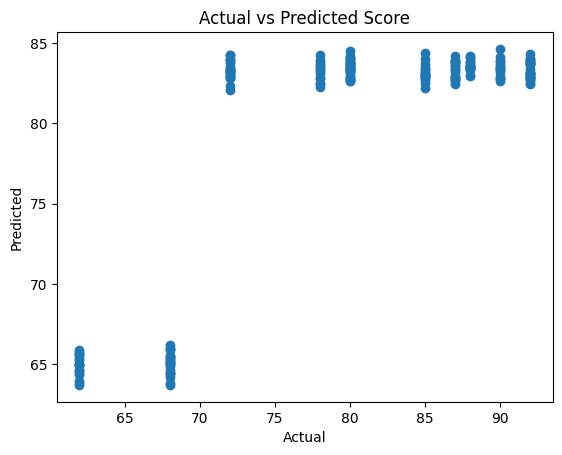

In [76]:
plt.scatter(y_test2, y_pred2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Score")
plt.show()

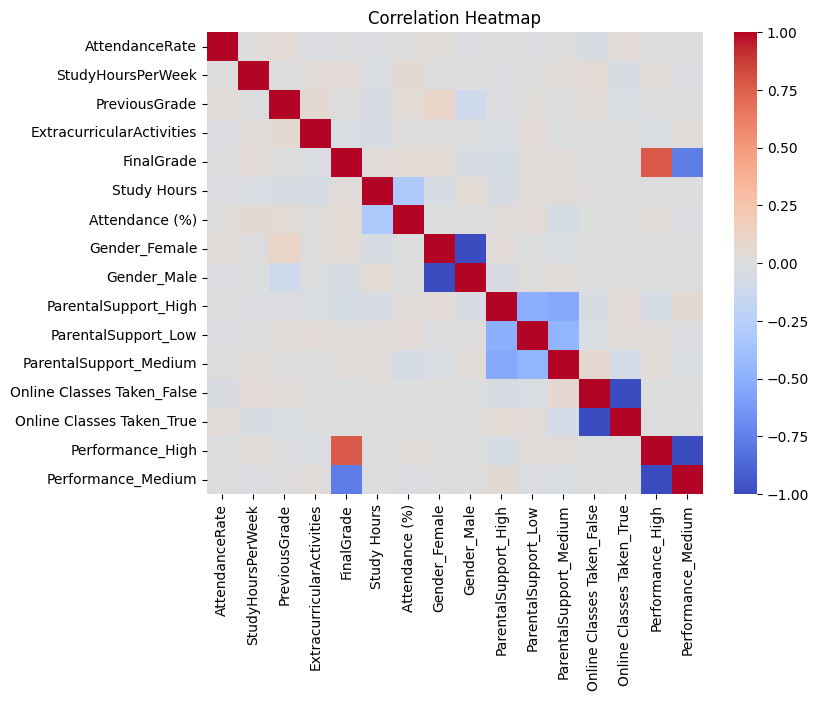

In [77]:
plt.figure(figsize=(8,6))
sns.heatmap(df_encoded.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()